# 02 — MLP sur caractéristiques statistiques

Le MLP reçoit des caractéristiques globales extraites de chaque fenêtre WESAD. La sélection des caractéristiques, leur normalisation, l'initialisation, la pondération de la perte et le seuil sont déterminés sans utiliser le test.

## 1. Configuration, données et protection contre les fuites

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from src.config import *
from src.evaluation import binary_metrics, collect_probabilities, per_subject_metrics, prediction_table, select_threshold, validate_per_subject_columns
from src.helpers import count_parameters, set_seed
from src.training import pos_weight_from_labels, save_model_artifacts, train_with_early_stopping

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Périphérique :", device, "| CUDA :", torch.cuda.is_available())


import joblib
from sklearn.preprocessing import StandardScaler
from src.preprocessing import extract_feature_table
from src.models import MLPClassifier, initialize_linear_layers

raw_dir = PROJECT_ROOT / "data" / "processed" / "sequence"
metadata_dir = PROJECT_ROOT / "data" / "processed" / "metadata"
X_train_seq = torch.load(raw_dir / "X_train_raw.pt", map_location="cpu", weights_only=True).float()
X_validation_seq = torch.load(raw_dir / "X_validation_raw.pt", map_location="cpu", weights_only=True).float()
X_test_seq = torch.load(raw_dir / "X_test_raw.pt", map_location="cpu", weights_only=True).float()
y_train = torch.load(raw_dir / "y_train.pt", map_location="cpu", weights_only=True).float()
y_validation = torch.load(raw_dir / "y_validation.pt", map_location="cpu", weights_only=True).float()
y_test = torch.load(raw_dir / "y_test.pt", map_location="cpu", weights_only=True).float()
metadata_train = pd.read_csv(metadata_dir / "windows_train.csv")
metadata_validation = pd.read_csv(metadata_dir / "windows_validation.csv")
metadata_test = pd.read_csv(metadata_dir / "windows_test.csv")
assert set(metadata_train.subject_id).isdisjoint(metadata_validation.subject_id)
assert set(metadata_train.subject_id).isdisjoint(metadata_test.subject_id)
assert set(metadata_validation.subject_id).isdisjoint(metadata_test.subject_id)

Périphérique : cuda | CUDA : True


## 2. Extraction, filtrage et normalisation ajustés sur l'entraînement

Les doublons exacts, constantes et corrélations supérieures à 0,95 sont identifiés uniquement dans l'entraînement. Le `StandardScaler` est lui aussi ajusté uniquement sur ces sujets, puis appliqué sans réajustement à validation et test.

In [2]:
feature_frames = {
    "train": extract_feature_table(X_train_seq.numpy()),
    "validation": extract_feature_table(X_validation_seq.numpy()),
    "test": extract_feature_table(X_test_seq.numpy()),
}
columns = list(feature_frames["train"].columns)
duplicates = [c for c, duplicate in zip(columns, feature_frames["train"].T.duplicated()) if duplicate]
columns = [c for c in columns if c not in duplicates]
constants = [c for c in columns if feature_frames["train"][c].nunique(dropna=False) <= 1]
columns = [c for c in columns if c not in constants]
upper = feature_frames["train"][columns].corr().abs().where(np.triu(np.ones((len(columns), len(columns))), 1).astype(bool))
correlated = [c for c in upper.columns if (upper[c] > 0.95).any()]
feature_columns = [c for c in columns if c not in correlated]

feature_scaler = StandardScaler().fit(feature_frames["train"][feature_columns])
X_train = torch.tensor(feature_scaler.transform(feature_frames["train"][feature_columns]), dtype=torch.float32)
X_validation = torch.tensor(feature_scaler.transform(feature_frames["validation"][feature_columns]), dtype=torch.float32)
X_test = torch.tensor(feature_scaler.transform(feature_frames["test"][feature_columns]), dtype=torch.float32)
train_dataset = TensorDataset(X_train, y_train)
def make_train_loader():
    return DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(RANDOM_SEED))
validation_loader = DataLoader(TensorDataset(X_validation, y_validation), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)
preprocessing_artifacts = PROJECT_ROOT / "artifacts/preprocessing"; preprocessing_artifacts.mkdir(parents=True, exist_ok=True)
(preprocessing_artifacts / "feature_columns.json").write_text(json.dumps(feature_columns, indent=2), encoding="utf-8")
(preprocessing_artifacts / "feature_selection.json").write_text(json.dumps({
    "fit_split": "train", "removed_exact_duplicates": duplicates, "removed_constants": constants,
    "removed_high_correlations": correlated, "correlation_threshold": 0.95,
}, indent=2), encoding="utf-8")
joblib.dump(feature_scaler, preprocessing_artifacts / "mlp_feature_scaler.joblib")
print(X_train.shape, "caractéristiques conservées :", len(feature_columns))

torch.Size([1429, 75]) caractéristiques conservées : 75


## 3. Deux implémentations strictement équivalentes

In [3]:
def build_sequential_mlp(input_dim: int, dropout: float = 0.3) -> nn.Sequential:
    return nn.Sequential(
        nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(dropout),
        nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(dropout),
        nn.Linear(64, 1),
    )

sequential_model = build_sequential_mlp(X_train.shape[1]).to(device)
custom_model = MLPClassifier(X_train.shape[1]).to(device)
assert count_parameters(sequential_model) == count_parameters(custom_model)
assert sequential_model(X_train[:4].to(device)).shape == custom_model(X_train[:4].to(device)).shape == (4, 1)
print(sequential_model)
print(custom_model)
print("Paramètres entraînables :", count_parameters(custom_model))

Sequential(
  (0): Linear(in_features=75, out_features=128, bias=True)
  (1): ReLU()
  (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=64, out_features=1, bias=True)
)
MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=75, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
Paramètres entraînable

## 4. `named_parameters()`, `state_dict()` et initialisations

In [4]:
for name, parameter in custom_model.named_parameters():
    print(name, tuple(parameter.shape), "trainable=", parameter.requires_grad)
print("Clés state_dict :", list(custom_model.state_dict()))

for method in ("gaussian", "constant", "xavier"):
    probe = MLPClassifier(X_train.shape[1])
    initialize_linear_layers(probe, method)
    first_weight = next(module.weight for module in probe.modules() if isinstance(module, nn.Linear))
    print(method, "mean=", float(first_weight.mean()), "std=", float(first_weight.std()))

net.0.weight (128, 75) trainable= True
net.0.bias (128,) trainable= True
net.2.weight (128,) trainable= True
net.2.bias (128,) trainable= True
net.4.weight (64, 128) trainable= True
net.4.bias (64,) trainable= True
net.6.weight (64,) trainable= True
net.6.bias (64,) trainable= True
net.8.weight (1, 64) trainable= True
net.8.bias (1,) trainable= True
Clés state_dict : ['net.0.weight', 'net.0.bias', 'net.2.weight', 'net.2.bias', 'net.2.running_mean', 'net.2.running_var', 'net.2.num_batches_tracked', 'net.4.weight', 'net.4.bias', 'net.6.weight', 'net.6.bias', 'net.6.running_mean', 'net.6.running_var', 'net.6.num_batches_tracked', 'net.8.weight', 'net.8.bias']
gaussian mean= 1.7972992282011546e-05 std= 0.020229706540703773
constant mean= 0.009999999776482582 std= 0.0
xavier mean= -0.0011135609820485115 std= 0.0991896539926529


C:\Users\User\AppData\Local\Temp\ipykernel_14880\3166062978.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print(method, "mean=", float(first_weight.mean()), "std=", float(first_weight.std()))


## 5. Sélection de l'initialisation sur validation

Les trois modèles utilisent la même architecture, les mêmes données et la même graine. L'initialisation maximisant le macro-F1 de validation est gelée avant toute évaluation test. Une initialisation constante est incluse à titre pédagogique ; sa symétrie peut pénaliser l'apprentissage.

In [5]:
RUN_MLP_TRAINING = True
initialization_runs = {}
if RUN_MLP_TRAINING:
    for method in ("gaussian", "constant", "xavier"):
        set_seed(RANDOM_SEED)
        candidate = MLPClassifier(X_train.shape[1]).to(device)
        initialize_linear_layers(candidate, method)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(candidate.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        candidate, history, summary = train_with_early_stopping(
            candidate, make_train_loader(), validation_loader, criterion, optimizer, device,
            max_epochs=MAX_EPOCHS, patience=PATIENCE,
        )
        probabilities, labels = collect_probabilities(candidate, validation_loader, device)
        candidate_threshold, _ = select_threshold(labels, probabilities)
        metrics = binary_metrics(labels, probabilities, candidate_threshold)
        initialization_runs[method] = dict(model=candidate, history=history, summary=summary, threshold=candidate_threshold, metrics=metrics)
    initialization_table = pd.DataFrame([
        {"initialization": name, "validation_macro_f1": run["metrics"]["macro_f1"], "threshold": run["threshold"], "best_epoch": run["summary"]["best_epoch"]}
        for name, run in initialization_runs.items()
    ]).sort_values("validation_macro_f1", ascending=False)
    display(initialization_table)
    selected_initialization = initialization_table.iloc[0]["initialization"]
    initialization_artifact_dir = PROJECT_ROOT / "artifacts/models/mlp"
    initialization_artifact_dir.mkdir(parents=True, exist_ok=True)
    initialization_table.to_csv(initialization_artifact_dir / "initialization_validation_results.csv", index=False)
    (initialization_artifact_dir / "selected_initialization.json").write_text(
        json.dumps({"initialization": selected_initialization, "selected_on": "validation_macro_f1"}, indent=2),
        encoding="utf-8",
    )
else:
    print("Non exécuté : activer RUN_MLP_TRAINING pour sélectionner l'initialisation sur validation.")

Epoch 001/100 | train_loss=0.4963 | validation_loss=0.5853 | best_epoch=1 *
Epoch 002/100 | train_loss=0.2603 | validation_loss=0.4002 | best_epoch=2 *
Epoch 003/100 | train_loss=0.1495 | validation_loss=0.3590 | best_epoch=3 *
Epoch 004/100 | train_loss=0.1028 | validation_loss=0.3798 | best_epoch=3


Epoch 005/100 | train_loss=0.0738 | validation_loss=0.4080 | best_epoch=3
Epoch 006/100 | train_loss=0.0566 | validation_loss=0.4539 | best_epoch=3
Epoch 007/100 | train_loss=0.0420 | validation_loss=0.5059 | best_epoch=3
Epoch 008/100 | train_loss=0.0325 | validation_loss=0.4802 | best_epoch=3


Epoch 009/100 | train_loss=0.0287 | validation_loss=0.4843 | best_epoch=3
Epoch 010/100 | train_loss=0.0272 | validation_loss=0.4760 | best_epoch=3
Epoch 011/100 | train_loss=0.0282 | validation_loss=0.5126 | best_epoch=3
Epoch 012/100 | train_loss=0.0201 | validation_loss=0.5221 | best_epoch=3


Epoch 013/100 | train_loss=0.0186 | validation_loss=0.3802 | best_epoch=3
Early stopping after 13 epochs (no validation-loss improvement for 10 epochs).


Epoch 001/100 | train_loss=0.5378 | validation_loss=0.6150 | best_epoch=1 *
Epoch 002/100 | train_loss=0.2891 | validation_loss=0.4482 | best_epoch=2 *
Epoch 003/100 | train_loss=0.1781 | validation_loss=0.5192 | best_epoch=2
Epoch 004/100 | train_loss=0.1400 | validation_loss=0.4422 | best_epoch=4 *


...

Epoch 005/100 | train_loss=0.1353 | validation_loss=0.3612 | best_epoch=5 *
Epoch 006/100 | train_loss=0.1269 | validation_loss=0.3708 | best_epoch=5
Epoch 007/100 | train_loss=0.0978 | validation_loss=0.3490 | best_epoch=7 *
Epoch 008/100 | train_loss=0.0830 | validation_loss=0.3600 | best_epoch=7


Epoch 009/100 | train_loss=0.0821 | validation_loss=0.3687 | best_epoch=7
Epoch 010/100 | train_loss=0.0731 | validation_loss=0.3643 | best_epoch=7
Epoch 011/100 | train_loss=0.0671 | validation_loss=0.3938 | best_epoch=7
Epoch 012/100 | train_loss=0.0524 | validation_loss=0.3603 | best_epoch=7


Epoch 013/100 | train_loss=0.0481 | validation_loss=0.3979 | best_epoch=7
Epoch 014/100 | train_loss=0.0507 | validation_loss=0.3804 | best_epoch=7
Epoch 015/100 | train_loss=0.0382 | validation_loss=0.4235 | best_epoch=7
Epoch 016/100 | train_loss=0.0433 | validation_loss=0.4327 | best_epoch=7


Epoch 017/100 | train_loss=0.0344 | validation_loss=0.4562 | best_epoch=7
Early stopping after 17 epochs (no validation-loss improvement for 10 epochs).


,initialization,validation_macro_f1,threshold,best_epoch
0,gaussian,0.879317,0.66,3
2,xavier,0.859615,0.44,7
1,constant,0.836489,0.15,4


## 6. Pondération, entraînement final et seuil de validation

In [6]:
if RUN_MLP_TRAINING:
    variants = []
    for weighted in (False, True):
        set_seed(RANDOM_SEED)
        candidate = MLPClassifier(X_train.shape[1]).to(device)
        initialize_linear_layers(candidate, selected_initialization)
        weight = pos_weight_from_labels(y_train, device) if weighted else None
        criterion = nn.BCEWithLogitsLoss(pos_weight=weight)
        optimizer = torch.optim.Adam(candidate.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        candidate, history, summary = train_with_early_stopping(candidate, make_train_loader(), validation_loader, criterion, optimizer, device, MAX_EPOCHS, PATIENCE)
        probabilities, labels = collect_probabilities(candidate, validation_loader, device)
        candidate_threshold, _ = select_threshold(labels, probabilities)
        metrics = binary_metrics(labels, probabilities, candidate_threshold)
        variants.append(dict(model=candidate, history=history, summary=summary, threshold=candidate_threshold, metrics=metrics, weighted=weighted))
    selected = max(variants, key=lambda run: run["metrics"]["macro_f1"])
    model, history, threshold = selected["model"], selected["history"], selected["threshold"]
    validation_metrics = selected["metrics"]
    test_start = time.perf_counter(); test_probabilities, test_true = collect_probabilities(model, test_loader, device); inference_time = time.perf_counter() - test_start
    test_metrics = {**binary_metrics(test_true, test_probabilities, threshold), "inference_time_seconds": inference_time}
    subject_metrics = per_subject_metrics(metadata_test, test_true, test_probabilities, threshold)
    display(pd.DataFrame({"validation": pd.Series(validation_metrics), "test": pd.Series(test_metrics)}))

Epoch 001/100 | train_loss=0.4963 | validation_loss=0.5853 | best_epoch=1 *
Epoch 002/100 | train_loss=0.2603 | validation_loss=0.4002 | best_epoch=2 *
Epoch 003/100 | train_loss=0.1495 | validation_loss=0.3590 | best_epoch=3 *
Epoch 004/100 | train_loss=0.1028 | validation_loss=0.3798 | best_epoch=3


Epoch 005/100 | train_loss=0.0738 | validation_loss=0.4080 | best_epoch=3
Epoch 006/100 | train_loss=0.0566 | validation_loss=0.4539 | best_epoch=3
Epoch 007/100 | train_loss=0.0420 | validation_loss=0.5059 | best_epoch=3
Epoch 008/100 | train_loss=0.0325 | validation_loss=0.4802 | best_epoch=3


Epoch 009/100 | train_loss=0.0287 | validation_loss=0.4843 | best_epoch=3
Epoch 010/100 | train_loss=0.0272 | validation_loss=0.4760 | best_epoch=3
Epoch 011/100 | train_loss=0.0282 | validation_loss=0.5126 | best_epoch=3
Epoch 012/100 | train_loss=0.0201 | validation_loss=0.5221 | best_epoch=3


Epoch 013/100 | train_loss=0.0186 | validation_loss=0.3802 | best_epoch=3
Early stopping after 13 epochs (no validation-loss improvement for 10 epochs).


Epoch 001/100 | train_loss=0.6553 | validation_loss=0.8109 | best_epoch=1 *
Epoch 002/100 | train_loss=0.3188 | validation_loss=0.5301 | best_epoch=2 *
Epoch 003/100 | train_loss=0.1906 | validation_loss=0.4981 | best_epoch=3 *
Epoch 004/100 | train_loss=0.1345 | validation_loss=0.5243 | best_epoch=3


Epoch 005/100 | train_loss=0.0949 | validation_loss=0.5477 | best_epoch=3
Epoch 006/100 | train_loss=0.0703 | validation_loss=0.6456 | best_epoch=3
Epoch 007/100 | train_loss=0.0560 | validation_loss=0.6230 | best_epoch=3
Epoch 008/100 | train_loss=0.0497 | validation_loss=0.6649 | best_epoch=3


Epoch 009/100 | train_loss=0.0433 | validation_loss=0.6483 | best_epoch=3
Epoch 010/100 | train_loss=0.0457 | validation_loss=0.7000 | best_epoch=3
Epoch 011/100 | train_loss=0.0507 | validation_loss=0.6270 | best_epoch=3
Epoch 012/100 | train_loss=0.0266 | validation_loss=0.6752 | best_epoch=3


Epoch 013/100 | train_loss=0.0233 | validation_loss=0.6310 | best_epoch=3
Early stopping after 13 epochs (no validation-loss improvement for 10 epochs).


,validation,test
accuracy,0.89547,0.887324
average_precision,0.85826,0.905258
confusion_matrix,"[[181, 20], [10, 76]]","[[288, 10], [38, 90]]"
inference_time_seconds,NaN,0.006048
macro_f1,0.879317,0.856275
non_stress_precision,0.947644,0.883436
non_stress_recall,0.900498,0.966443
roc_auc,0.929076,0.95011
stress_precision,0.791667,0.9
stress_recall,0.883721,0.703125


## 6.1 Courbes d'entraînement et matrice de confusion

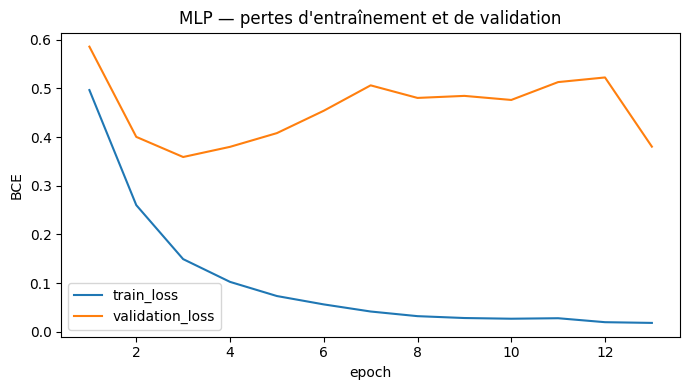

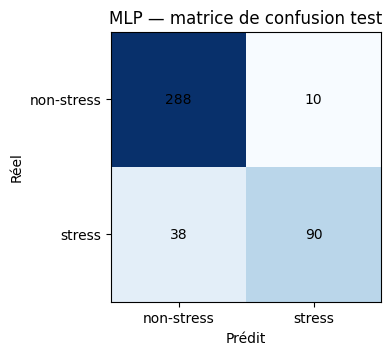

In [7]:
if RUN_MLP_TRAINING:
    fig, ax = plt.subplots(figsize=(7, 4))
    history.plot(x="epoch", y=["train_loss", "validation_loss"], ax=ax)
    ax.set(title="MLP — pertes d'entraînement et de validation", ylabel="BCE")
    plt.tight_layout(); plt.show()
    cm = np.asarray(test_metrics["confusion_matrix"])
    fig, ax = plt.subplots(figsize=(4, 4)); ax.imshow(cm, cmap="Blues")
    ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["non-stress", "stress"], yticklabels=["non-stress", "stress"], xlabel="Prédit", ylabel="Réel")
    for row in range(2):
        for col in range(2): ax.text(col, row, cm[row, col], ha="center", va="center")
    ax.set_title("MLP — matrice de confusion test"); plt.tight_layout(); plt.show()

## 7. Sauvegarde et rechargement du meilleur `state_dict`

In [8]:
if RUN_MLP_TRAINING:
    artifact_dir = PROJECT_ROOT / "artifacts/models/mlp"
    save_model_artifacts(
        artifact_dir, model,
        {"model": "MLPClassifier", "input_dim": X_train.shape[1], "parameter_count": count_parameters(model), "initialization": selected_initialization,
         "selected_imbalance_method": "class_weight" if selected["weighted"] else "no_correction",
         "subject_split": SPLIT_SUBJECTS, "input_representation": "statistical_features", "feature_scaler_fit": "train", "seed": RANDOM_SEED,
         "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY, "batch_size": BATCH_SIZE,
         "maximum_epochs": MAX_EPOCHS, "patience": PATIENCE, "classification_threshold": threshold,
         "artifact_paths": {"state_dict": "artifacts/models/mlp/best_model.pt", "feature_scaler": "artifacts/preprocessing/mlp_feature_scaler.joblib"}},
        threshold, history, validation_metrics, test_metrics, subject_metrics,
        prediction_table(metadata_test, test_true, test_probabilities, threshold),
        {**selected["summary"], "selected_initialization": selected_initialization,
         "selected_imbalance_method": "class_weight" if selected["weighted"] else "no_correction", "inference_time_seconds": inference_time},
    )
    before = model.eval()(X_test[:8].to(device)).detach()
    reloaded = MLPClassifier(X_train.shape[1]).to(device)
    reloaded.load_state_dict(torch.load(artifact_dir / "best_model.pt", map_location=device, weights_only=True)); reloaded.eval()
    after = reloaded(X_test[:8].to(device)).detach()
    torch.testing.assert_close(before, after)
    print("Rechargement vérifié.")

Rechargement vérifié.


## 8. Métriques disponibles

`binary_metrics` rapporte exactitude, précision et rappel par classe, macro-F1, F1 pondéré, ROC-AUC, average precision et matrice de confusion. Les valeurs existantes ci-dessous proviennent uniquement des artefacts réellement générés.

In [9]:
artifact_dir = PROJECT_ROOT / "artifacts/models/mlp"
if (artifact_dir / "test_metrics.json").exists():
    with (artifact_dir / "test_metrics.json").open(encoding="utf-8") as handle: display(pd.Series(json.load(handle), name="test"))
else:
    print("Artefact MLP absent.")

accuracy                               0.887324
macro_f1                               0.856275
weighted_f1                            0.882933
non_stress_precision                   0.883436
non_stress_recall                      0.966443
stress_precision                            0.9
stress_recall                          0.703125
confusion_matrix          [[288, 10], [38, 90]]
roc_auc                                 0.95011
average_precision                      0.905258
inference_time_seconds                 0.006048
Name: test, dtype: object